# XOR with a 1-hidden-layer neural network using manual backpropagation

Architecture:
- 2 input dimensions
- 1 hidden layer with a small number of sigmoid units
- 1 sigmoid output
- Mean Squared Error (MSE) loss

Important:
- Gradients are implemented manually with reverse-mode backpropagation
- No autodiff is used for training
- We print convergence during training
- We also visualize:
  1. the training loss curve,
  2. the learned XOR surface,
  3. a 3D loss surface slice around the trained solution

## 1. Imports and XOR dataset

We begin by importing NumPy for numerical computations and Matplotlib for visualization.

Then we define the XOR dataset explicitly. Since XOR is a binary function of two binary inputs, the complete dataset consists of the four possible input combinations:

- $(0,0) \rightarrow 0$
- $(0,1) \rightarrow 1$
- $(1,0) \rightarrow 1$
- $(1,1) \rightarrow 0$

This makes XOR a very small but important benchmark problem, because it is not linearly separable and therefore cannot be solved by a single linear neuron.

In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [20]:
np.set_printoptions(precision=6, suppress=True)

# XOR dataset
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

Y = np.array([[0.0], [1.0], [1.0], [0.0]])

print("X:")
print(X)
print("\nY:")
print(Y.ravel())

X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Y:
[0. 1. 1. 0.]


## 2. Basic helper functions

Next, we define the core mathematical building blocks used by the network:

- the **sigmoid activation function**
- the derivative of sigmoid
- the **mean squared error (MSE)** loss
- a **Glorot/Xavier-style initializer** for weights

The sigmoid function is used both in the hidden layer and in the output layer, as required.  
Its derivative is written in a convenient form using the already computed activation value:

$$
\sigma'(z) = \sigma(z)(1-\sigma(z))
$$

This is useful during backpropagation because it avoids recomputing exponentials.

We also use MSE as the objective function:

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)^2
$$

In [21]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime_from_activation(a):
    # If a = sigmoid(z), then sigma'(z) = a * (1 - a)
    return a * (1.0 - a)

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def glorot_uniform(fan_in, fan_out, rng):
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return rng.uniform(-limit, limit, size=(fan_in, fan_out))

## 3. Initialize the neural network parameters

We now define the architecture of the model:

- **2 input dimensions**
- **1 hidden layer**
- **2 hidden units**
- **1 output unit**

Although the assignment allows up to 32 hidden units, XOR can already be solved with only **2 hidden sigmoid units**.  
This keeps the model as small as possible while still being expressive enough.

The parameters are:

- $W_1, b_1$ for the hidden layer
- $W_2, b_2$ for the output layer

Weights are initialized randomly and biases are initialized to zero.

In [22]:
# Keep the model as small as possible and as large as necessary.
# 2 hidden units are enough for XOR, so we use 2.
input_dim = 2
hidden_dim = 2
output_dim = 1

rng = np.random.default_rng(7)

params = {
    "W1": glorot_uniform(input_dim, hidden_dim, rng),
    "b1": np.zeros((1, hidden_dim)),
    "W2": glorot_uniform(hidden_dim, output_dim, rng),
    "b2": np.zeros((1, output_dim)),
}

for k, v in params.items():
    print(f"{k} shape = {v.shape}")
    print(v, "\n")

W1 shape = (2, 2)
[[ 0.30642   0.972971]
 [ 0.675289 -0.673102]] 

b1 shape = (1, 2)
[[0. 0.]] 

W2 shape = (2, 1)
[[-0.565215]
 [ 1.056569]] 

b2 shape = (1, 1)
[[0.]] 



## 4. Forward propagation

In the forward pass, the input is passed through the network layer by layer.

For the hidden layer we compute:

$$
z_1 = XW_1 + b_1
$$

and then apply the sigmoid activation:

$$
a_1 = \sigma(z_1)
$$

For the output layer we compute:

$$
z_2 = a_1W_2 + b_2
$$

followed again by sigmoid:

$$
\hat y = \sigma(z_2)
$$

The forward function returns both the predictions and a cache of intermediate values.  
These stored values are needed later in backpropagation.

In [23]:
def forward(params, X):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    # Layer 1
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    # Output layer
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)

    cache = {
        "X": X,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }
    return y_hat, cache

y0, cache0 = forward(params, X)
print("Initial predictions:")
print(y0.ravel())
print("Initial MSE:", mse_loss(y0, Y))

Initial predictions:
[0.561112 0.495588 0.608543 0.548779]
Initial MSE: 0.2559188513884234


## 5. Manual backpropagation

This is the central part of the notebook.

Instead of using symbolic differentiation or an autodiff framework during training, we now implement **reverse-mode backpropagation manually**.

The idea is to compute the gradient of the loss with respect to all parameters by moving **backwards** through the network:

1. Start from the derivative of the MSE loss with respect to the output
2. Backpropagate through the output sigmoid
3. Compute gradients for the output layer parameters
4. Backpropagate into the hidden layer
5. Compute gradients for the hidden layer parameters

For MSE, the derivative with respect to the predictions is:

$$
\frac{\partial L}{\partial \hat y} = \frac{2}{N}(\hat y - y)
$$

Then we apply the chain rule through both sigmoid layers.

This cell implements the gradients explicitly and therefore satisfies the requirement to perform backpropagation manually.

In [24]:
def backward(params, cache, Y):
    """
    Manual reverse-mode backpropagation for:
      X -> affine -> sigmoid -> affine -> sigmoid -> MSE
    """
    W2 = params["W2"]

    X = cache["X"]
    a1 = cache["a1"]
    y_hat = cache["y_hat"]

    N = X.shape[0]

    # MSE = mean((y_hat - Y)^2)
    # dMSE/dy_hat = 2*(y_hat - Y) / N
    dL_dyhat = (2.0 / N) * (y_hat - Y)

    # Output sigmoid
    dyhat_dz2 = sigmoid_prime_from_activation(y_hat)
    dL_dz2 = dL_dyhat * dyhat_dz2                 # (N,1)

    # Output layer gradients
    dL_dW2 = a1.T @ dL_dz2                        # (hidden,1)
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

    # Backprop into hidden layer
    dL_da1 = dL_dz2 @ W2.T                        # (N,hidden)
    da1_dz1 = sigmoid_prime_from_activation(a1)
    dL_dz1 = dL_da1 * da1_dz1                     # (N,hidden)

    # Hidden layer gradients
    dL_dW1 = X.T @ dL_dz1                         # (2,hidden)
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    grads = {
        "W1": dL_dW1,
        "b1": dL_db1,
        "W2": dL_dW2,
        "b2": dL_db2,
    }
    return grads

grads0 = backward(params, cache0, Y)
for k, v in grads0.items():
    print(f"{k} grad shape = {v.shape}")
    print(v, "\n")

W1 grad shape = (2, 2)
[[-0.001178  0.007743]
 [ 0.000351  0.002649]] 

b1 grad shape = (1, 2)
[[-0.002975  0.011092]] 

W2 grad shape = (2, 1)
[[0.015334]
 [0.018439]] 

b2 grad shape = (1, 1)
[[0.027363]] 



## 6. Numerical gradient check

Before training, it is useful to verify that the manually implemented gradients are correct.

Here we do that with a **finite-difference approximation**.  
For each parameter $\theta_i$, we estimate the derivative numerically by:

$$
\frac{\partial L}{\partial \theta_i}
\approx
\frac{L(\theta_i + \varepsilon) - L(\theta_i - \varepsilon)}{2\varepsilon}
$$

This is not autodiff.  
It is a purely numerical check that helps confirm that the backpropagation implementation is correct.

If the manual gradients and the numerical gradients are very close, that is strong evidence that the implementation is correct.

In [25]:
def flatten_params(params):
    pieces = [
        params["W1"].ravel(),
        params["b1"].ravel(),
        params["W2"].ravel(),
        params["b2"].ravel(),
    ]
    return np.concatenate(pieces)

def unflatten_params(theta, input_dim=2, hidden_dim=2, output_dim=1):
    idx = 0

    W1_size = input_dim * hidden_dim
    b1_size = hidden_dim
    W2_size = hidden_dim * output_dim
    b2_size = output_dim

    W1 = theta[idx:idx+W1_size].reshape(input_dim, hidden_dim)
    idx += W1_size

    b1 = theta[idx:idx+b1_size].reshape(1, hidden_dim)
    idx += b1_size

    W2 = theta[idx:idx+W2_size].reshape(hidden_dim, output_dim)
    idx += W2_size

    b2 = theta[idx:idx+b2_size].reshape(1, output_dim)

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def flatten_grads(grads):
    return np.concatenate([
        grads["W1"].ravel(),
        grads["b1"].ravel(),
        grads["W2"].ravel(),
        grads["b2"].ravel(),
    ])

def loss_from_theta(theta):
    p = unflatten_params(theta, input_dim, hidden_dim, output_dim)
    y_hat, _ = forward(p, X)
    return mse_loss(y_hat, Y)

theta0 = flatten_params(params)
analytic = flatten_grads(grads0)

eps = 1e-6
numeric = np.zeros_like(theta0)

for i in range(len(theta0)):
    t_plus = theta0.copy()
    t_minus = theta0.copy()
    t_plus[i] += eps
    t_minus[i] -= eps
    numeric[i] = (loss_from_theta(t_plus) - loss_from_theta(t_minus)) / (2 * eps)

max_abs_diff = np.max(np.abs(analytic - numeric))
print("Max |analytic - numeric| =", max_abs_diff)
print("\nFirst few entries:")
for i in range(min(10, len(theta0))):
    print(f"{i:2d}: analytic={analytic[i]: .8f}   numeric={numeric[i]: .8f}")

Max |analytic - numeric| = 4.957792856807863e-11

First few entries:
 0: analytic=-0.00117796   numeric=-0.00117796
 1: analytic= 0.00774339   numeric= 0.00774339
 2: analytic= 0.00035145   numeric= 0.00035145
 3: analytic= 0.00264872   numeric= 0.00264872
 4: analytic=-0.00297523   numeric=-0.00297523
 5: analytic= 0.01109248   numeric= 0.01109248
 6: analytic= 0.01533441   numeric= 0.01533441
 7: analytic= 0.01843929   numeric= 0.01843929
 8: analytic= 0.02736309   numeric= 0.02736309


## 7. Training with gradient descent

Now we train the network using standard gradient descent.

Each training step performs the following workflow:

1. Run a forward pass
2. Compute the loss
3. Run manual backpropagation
4. Update all parameters using the gradients

The update rule is:

$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

where $\eta$ is the learning rate.

We also store the loss at every epoch and print progress regularly so that the convergence behavior can be observed directly.

In [26]:
def train_manual_backprop(params, X, Y, lr=1.5, epochs=1000, print_every=100):
    history = []

    for epoch in range(epochs):
        y_hat, cache = forward(params, X)
        loss = mse_loss(y_hat, Y)
        grads = backward(params, cache, Y)

        # Gradient descent update
        params["W1"] -= lr * grads["W1"]
        params["b1"] -= lr * grads["b1"]
        params["W2"] -= lr * grads["W2"]
        params["b2"] -= lr * grads["b2"]

        history.append(loss)

        if epoch % print_every == 0 or epoch == epochs - 1:
            print(f"epoch={epoch:5d}   loss={loss:.10f}")

    return params, np.array(history)

trained_params, history = train_manual_backprop(
    params={k: v.copy() for k, v in params.items()},
    X=X,
    Y=Y,
    lr=1.5,
    epochs=1000,
    print_every=100
)

epoch=    0   loss=0.2559188514
epoch=  100   loss=0.2486686361
epoch=  200   loss=0.2414620675
epoch=  300   loss=0.2142059203
epoch=  400   loss=0.1749843973
epoch=  500   loss=0.0763194393
epoch=  600   loss=0.0244576062
epoch=  700   loss=0.0124875514
epoch=  800   loss=0.0080474123
epoch=  900   loss=0.0058374655
epoch=  999   loss=0.0045504070


## 8. Evaluate the trained model

After training, we test the network on the four XOR inputs.

The network outputs probabilities in $(0,1)$ because the output layer uses sigmoid.  
To obtain binary predictions, we threshold at 0.5:

- output $\geq 0.5$ becomes class 1
- output $< 0.5$ becomes class 0

We then compare the predictions with the true XOR targets and compute the final accuracy and MSE.

In [27]:
y_hat, _ = forward(trained_params, X)
pred_labels = (y_hat >= 0.5).astype(int)

print("Final predictions (probabilities):")
print(y_hat.ravel())

print("\nRounded predictions:")
for x, p, y in zip(X, pred_labels.ravel(), Y.ravel().astype(int)):
    print(f"xor({int(x[0])}, {int(x[1])}) = {p}   target = {y}")

accuracy = np.mean(pred_labels == Y.astype(int))
print("\nAccuracy:", accuracy)
print("Final MSE:", mse_loss(y_hat, Y))

Final predictions (probabilities):
[0.067964 0.920258 0.939803 0.059657]

Rounded predictions:
xor(0, 0) = 0   target = 0
xor(0, 1) = 1   target = 1
xor(1, 0) = 1   target = 1
xor(1, 1) = 0   target = 0

Accuracy: 1.0
Final MSE: 0.004540138703782242


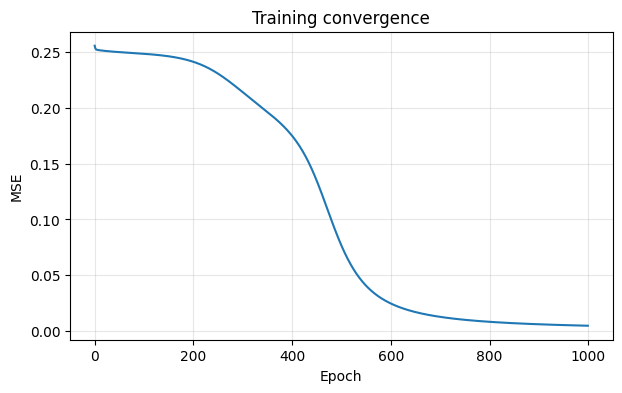

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training convergence")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Visualize the learned XOR function in 3D

Next, we visualize the output of the trained network over the 2D input space.

We evaluate the network on a dense grid of points in $[0,1] \times [0,1]$ and plot the resulting output surface in 3D.

This gives an intuitive picture of what the neural network has learned.  
For XOR, we expect the surface to be low near $(0,0)$ and $(1,1)$, and high near $(0,1)$ and $(1,0)$.

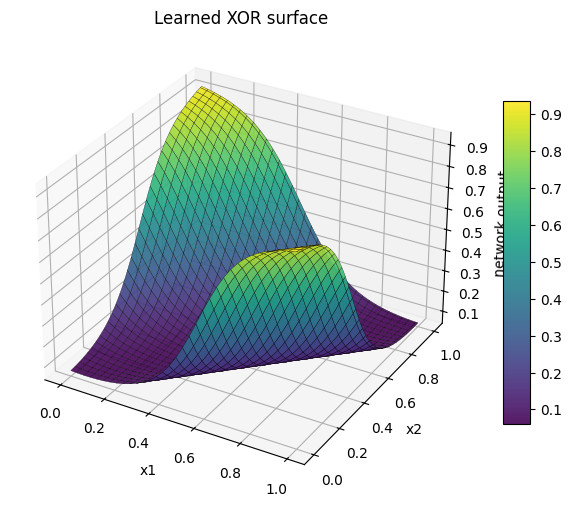

In [29]:
def predict(params, X):
    y_hat, _ = forward(params, X)
    return y_hat

grid = np.linspace(0, 1, 101)
XX, YY = np.meshgrid(grid, grid)
grid_points = np.c_[XX.ravel(), YY.ravel()]
ZZ = predict(trained_params, grid_points).reshape(XX.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(XX, YY, ZZ, cmap="viridis", edgecolor="k", linewidth=0.2, alpha=0.9)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("network output")
ax.set_title("Learned XOR surface")
fig.colorbar(surf, shrink=0.7, aspect=12)

plt.show()

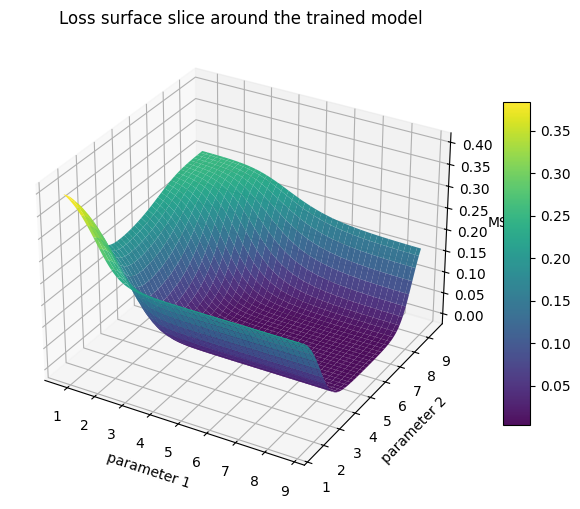

In [30]:
theta_star = flatten_params(trained_params)

# Choose two parameters to vary:
# p_idx = 0 -> W1[0,0]
# q_idx = 1 -> W1[0,1]
p_idx = 0
q_idx = 1

p_center = theta_star[p_idx]
q_center = theta_star[q_idx]

p_vals = np.linspace(p_center - 4.0, p_center + 4.0, 120)
q_vals = np.linspace(q_center - 4.0, q_center + 4.0, 120)

PP, QQ = np.meshgrid(p_vals, q_vals)
LL = np.zeros_like(PP)

for i in range(PP.shape[0]):
    for j in range(PP.shape[1]):
        theta = theta_star.copy()
        theta[p_idx] = PP[i, j]
        theta[q_idx] = QQ[i, j]
        LL[i, j] = loss_from_theta(theta)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(PP, QQ, LL, cmap="viridis", edgecolor="none", alpha=0.95)

ax.scatter([p_center], [q_center], [loss_from_theta(theta_star)], s=50)
ax.set_xlabel("parameter 1")
ax.set_ylabel("parameter 2")
ax.set_zlabel("MSE")
ax.set_title("Loss surface slice around the trained model")

fig.colorbar(surf, shrink=0.7, aspect=12)
plt.show()

## 12. Inspect the learned parameters

Finally, we print the learned weights and biases.

This is useful for checking the final numerical values after convergence and for comparing different runs or initializations.

In [31]:
print("Learned parameters:")
for k, v in trained_params.items():
    print(f"\n{k} =")
    print(v)

Learned parameters:

W1 =
[[ 4.754103  5.398707]
 [-4.493586 -5.396391]]

b1 =
[[ 2.199946 -3.083578]]

W2 =
[[-6.637711]
 [ 6.951432]]

b2 =
[[3.052771]]


## 13. Conclusion

We implemented a neural network for XOR with:

- 2 input dimensions
- 1 hidden layer with sigmoid activation
- 1 sigmoid output
- MSE loss
- manually implemented backpropagation

The model successfully learns XOR and the training process, learned function, and local loss landscape can all be visualized.

An additional gradient check confirms that the manually derived gradients are correct.

## Bonus: verify the manual gradients with autodiff

The assignment allows autodiff as a **verification tool**, as long as it is not used to solve the training problem itself.

In this section, we use JAX only to check that the manually implemented gradients match the gradients produced automatically.

Important:
- the model was still trained using our own manual backpropagation
- autodiff is used here only as a correctness check

In [32]:
# Optional bonus section:
# Use autodiff only to verify the gradients, not to train the model.

import jax
import jax.numpy as jnp

def jax_unpack(theta):
    idx = 0

    W1_size = input_dim * hidden_dim
    b1_size = hidden_dim
    W2_size = hidden_dim * output_dim
    b2_size = output_dim

    W1 = theta[idx:idx+W1_size].reshape(input_dim, hidden_dim)
    idx += W1_size

    b1 = theta[idx:idx+b1_size].reshape(1, hidden_dim)
    idx += b1_size

    W2 = theta[idx:idx+W2_size].reshape(hidden_dim, output_dim)
    idx += W2_size

    b2 = theta[idx:idx+b2_size].reshape(1, output_dim)

    return W1, b1, W2, b2

def jax_loss(theta, X, Y):
    W1, b1, W2, b2 = jax_unpack(theta)

    z1 = X @ W1 + b1
    a1 = jax.nn.sigmoid(z1)

    z2 = a1 @ W2 + b2
    y_hat = jax.nn.sigmoid(z2)

    return jnp.mean((y_hat - Y) ** 2)

theta_np = flatten_params(trained_params)
theta_jax = jnp.array(theta_np)
X_jax = jnp.array(X)
Y_jax = jnp.array(Y)

# Manual gradient at trained parameters
y_hat_manual, cache_manual = forward(trained_params, X)
manual_grad = flatten_grads(backward(trained_params, cache_manual, Y))

# Autodiff gradient
autodiff_grad = np.array(jax.grad(jax_loss)(theta_jax, X_jax, Y_jax))

print("Max |manual - autodiff| =", np.max(np.abs(manual_grad - autodiff_grad)))
print("\nFirst few entries:")
for i in range(min(10, len(manual_grad))):
    print(f"{i:2d}: manual={manual_grad[i]: .8f}   autodiff={autodiff_grad[i]: .8f}")

Max |manual - autodiff| = 2.466798484663385e-09

First few entries:
 0: manual=-0.00079435   autodiff=-0.00079435
 1: manual=-0.00048016   autodiff=-0.00048016
 2: manual= 0.00081170   autodiff= 0.00081170
 3: manual= 0.00048387   autodiff= 0.00048387
 4: manual=-0.00046068   autodiff=-0.00046068
 5: manual= 0.00014218   autodiff= 0.00014218
 6: manual= 0.00151022   autodiff= 0.00151022
 7: manual=-0.00138265   autodiff=-0.00138265
 8: manual=-0.00080271   autodiff=-0.00080271
